<a href="https://colab.research.google.com/github/Nikhil4002-50-82/Automatic-Pedicle-Screw-Planning/blob/main/GeometryForPedicleScrewPlanning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***Phase 1- Geometry Based Planning***

In [4]:
import numpy as np
import nibabel as nib
from scipy.ndimage import distance_transform_edt, label as cc_label
from scipy.ndimage import map_coordinates
from sklearn.decomposition import PCA

ct_path="/content/drive/MyDrive/SpineData/case_002/case_0000.nii"
seg_path="/content/drive/MyDrive/SpineData/case_002/spine_2-label.nii"

voxel_threshold=5000
diameters=[6.0,5.5,5.0,4.5,4.0]
step_mm=0.5
min_length_mm=18
direction_cone_deg_lr=35
direction_cone_deg_si=20
direction_samples_lr=13
direction_samples_si=9

w_dt=5.0
w_len=1.5
w_tilt=0.5

label_map={5:"L1",4:"L2",3:"L3",2:"L4",1:"L5"}

def load_nifti(path):
    nii=nib.load(path)
    return nii.get_fdata(), nii.header.get_zooms(), nii.affine

ct,spacing_ct,affine_ct=load_nifti(ct_path)
seg,spacing,affine=load_nifti(seg_path)

def get_valid_labels(seg):
    valid=[]
    for label_val in range(1,6):
        mask=(seg==label_val)
        if np.sum(mask)==0:
            continue
        labeled,nc=cc_label(mask)
        sizes=np.bincount(labeled.ravel())
        sizes[0]=0
        largest=np.argmax(sizes)
        component=(labeled==largest)
        if np.sum(component)>voxel_threshold:
            valid.append((label_val,component))
    return valid

valid_segments=get_valid_labels(seg)

def compute_stable_frame(mask,affine):
    coords=np.argwhere(mask)
    coords_world=nib.affines.apply_affine(affine,coords)
    centroid=coords_world.mean(axis=0)

    pca=PCA(n_components=3)
    pca.fit(coords_world-centroid)
    axes=pca.components_

    world_z=np.array([0,0,1])
    si=axes[np.argmax(np.abs(axes@world_z))]
    if np.dot(si,world_z)<0: si=-si

    # Orthogonal LR
    temp=axes[np.argmin(np.abs(axes@world_z))]
    lr=temp - np.dot(temp,si)*si
    lr/=np.linalg.norm(lr)

    ap=np.cross(si,lr)
    ap/=np.linalg.norm(ap)

    return centroid,np.vstack([si,lr,ap])

def compute_distance(mask):
    return distance_transform_edt(mask,sampling=spacing)

def pedicle_centers(mask,dist,centroid,axes,affine):
    coords=np.argwhere(mask)
    coords_world=nib.affines.apply_affine(affine,coords)

    si,lr,ap=axes
    rel=coords_world-centroid
    si_vals=rel@si
    lr_vals=rel@lr
    ap_vals=rel@ap

    mid_mask=np.abs(si_vals)<np.percentile(np.abs(si_vals),35)
    posterior_mask=ap_vals<np.percentile(ap_vals,40)

    left_mask=lr_vals<0
    right_mask=lr_vals>0

    left_coords=coords[mid_mask & posterior_mask & left_mask]
    right_coords=coords[mid_mask & posterior_mask & right_mask]

    if len(left_coords)<30 or len(right_coords)<30:
        return None,None

    l_vox=left_coords[np.argmax(dist[left_coords[:,0],
                                        left_coords[:,1],
                                        left_coords[:,2]])]
    r_vox=right_coords[np.argmax(dist[right_coords[:,0],
                                         right_coords[:,1],
                                         right_coords[:,2]])]

    l_mm=nib.affines.apply_affine(affine,l_vox)
    r_mm=nib.affines.apply_affine(affine,r_vox)

    return l_mm,r_mm

def find_entry(center,axes,mask_float,affine):
    si,lr,ap=axes
    direction=-ap
    inv_aff=np.linalg.inv(affine)
    p=center.copy()

    for _ in range(300):
        vox=nib.affines.apply_affine(inv_aff,p)
        if any(v<0 or v>=s-1 for v,s in zip(vox,mask_float.shape)):
            break
        val=map_coordinates(mask_float,
                            [[vox[0]],[vox[1]],[vox[2]]],
                            order=1)[0]
        if val<0.5:
            break
        p+=direction*step_mm

    return p+ap*1.0

def cylinder_safe(p,d,radius,mask_float,dist,affine):
    inv_aff=np.linalg.inv(affine)
    for angle in np.linspace(0,2*np.pi,8,endpoint=False):
        offset=radius*(np.cos(angle)*np.cross(d,[0,0,1])
                       +np.sin(angle)*np.cross(d,[1,0,0]))
        test_point=p+offset
        vox=nib.affines.apply_affine(inv_aff,test_point)
        if any(v<0 or v>=s-1 for v,s in zip(vox,mask_float.shape)):
            return False
        val=map_coordinates(mask_float,
                            [[vox[0]],[vox[1]],[vox[2]]],
                            order=1)[0]
        if val<0.5:
            return False
    return True

def evaluate(entry,direction,mask_float,dist,affine,radius,axes):
    d=direction/np.linalg.norm(direction)
    inv_aff=np.linalg.inv(affine)

    t=0
    min_dt=999

    while True:
        p=entry+d*t
        vox=nib.affines.apply_affine(inv_aff,p)
        if any(v<0 or v>=s-1 for v,s in zip(vox,mask_float.shape)):
            break
        mask_val=map_coordinates(mask_float,
                                 [[vox[0]],[vox[1]],[vox[2]]],
                                 order=1)[0]
        if mask_val<0.5:
            break

        dt_val=map_coordinates(dist,
                               [[vox[0]],[vox[1]],[vox[2]]],
                               order=1)[0]

        min_dt=min(min_dt,dt_val)

        if not cylinder_safe(p,d,radius,mask_float,dist,affine):
            break

        t+=step_mm

    if t<min_length_mm:
        return None

    si=axes[0]
    tilt=abs(np.dot(d,si))

    score=w_dt*min_dt + w_len*(t/10) - w_tilt*tilt

    return score,t,min_dt,p,d

def optimize(center,axes,mask_float,dist,affine):
    si,lr,ap=axes
    entry=find_entry(center,axes,mask_float,affine)
    best=None

    for diam in diameters:
        radius=diam/2
        for lr_ang in np.linspace(-direction_cone_deg_lr,
                                  direction_cone_deg_lr,
                                  direction_samples_lr):
            for si_ang in np.linspace(-direction_cone_deg_si,
                                      direction_cone_deg_si,
                                      direction_samples_si):

                direction=ap \
                    + np.tan(np.deg2rad(lr_ang))*lr \
                    + np.tan(np.deg2rad(si_ang))*si

                r=evaluate(entry,direction,
                           mask_float,dist,affine,
                           radius,axes)

                if r is None:
                    continue

                score,length,min_dt,tip,d=r

                if best is None or score>best[0]:
                    best=(score,entry,tip,length,min_dt,diam)

    return best

print("\nREFINED ROBUST PHASE-1:\n")

for label_val,mask in valid_segments:

    name=label_map.get(label_val,str(label_val))
    print("==============")
    print(name)
    print("==============")

    centroid,axes=compute_stable_frame(mask,affine)
    dist=compute_distance(mask)
    mask_float=mask.astype(np.float32)

    l_center,r_center=pedicle_centers(mask,dist,
                                      centroid,axes,
                                      affine)

    if l_center is None:
        print("Pedicle detection failed\n")
        continue

    for side,center in [("Left",l_center),
                        ("Right",r_center)]:

        result=optimize(center,axes,
                        mask_float,dist,
                        affine)

        if result is None:
            print(f"{side}: NO VALID PATH\n")
            continue

        score,entry,tip,length,min_dt,diam=result

        print(f"{side} Screw Found")
        print("Diameter:",diam,"mm")
        print("Length:",round(length,1),"mm")
        print("Safety Margin:",
              round(min_dt-diam/2,2),"mm")
        print()


REFINED ROBUST PHASE-1:

L5
Left: NO VALID PATH

Right Screw Found
Diameter: 5.5 mm
Length: 68.0 mm
Safety Margin: -1.49 mm

L4
Left: NO VALID PATH

Right: NO VALID PATH

L3
Left: NO VALID PATH

Right Screw Found
Diameter: 4.0 mm
Length: 29.5 mm
Safety Margin: -0.6 mm

L2
Left Screw Found
Diameter: 4.0 mm
Length: 27.0 mm
Safety Margin: -0.68 mm

Right: NO VALID PATH

L1
Left: NO VALID PATH

Right: NO VALID PATH



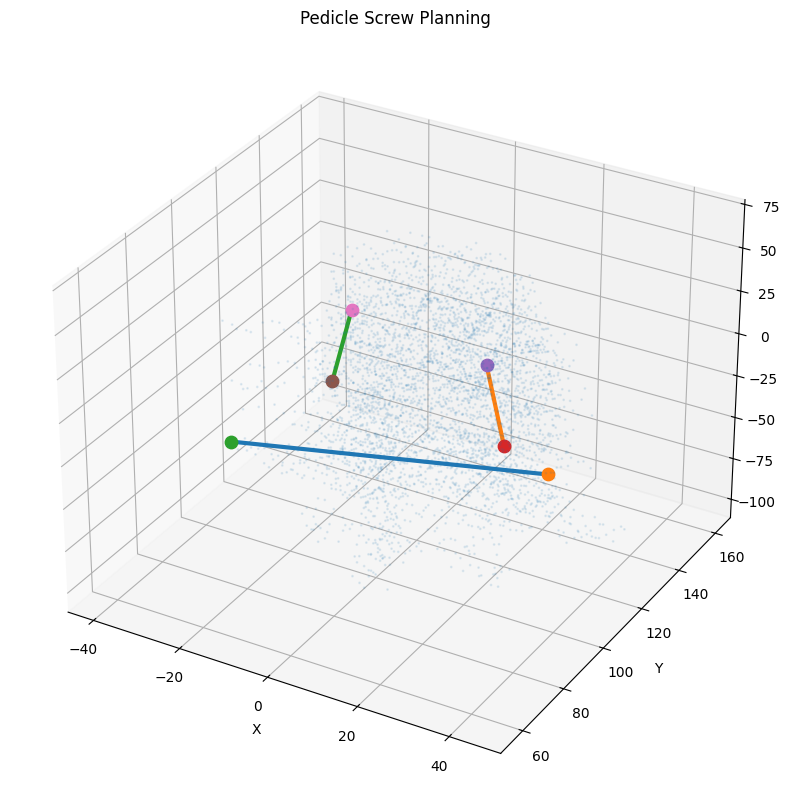

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import nibabel as nib
import numpy as np

############################################
# Reload segmentation (same as planner)
############################################

seg_nii = nib.load(seg_path)
seg_data = seg_nii.get_fdata()
affine = seg_nii.affine

############################################
# Collect trajectories again
############################################

trajectories=[]

for label_val,mask in valid_segments:

    centroid,axes=compute_stable_frame(mask,affine)
    dist=compute_distance(mask)
    mask_float=mask.astype(np.float32)

    l_center,r_center=pedicle_centers(mask,dist,
                                      centroid,axes,
                                      affine)

    if l_center is None:
        continue

    for side,center in [("Left",l_center),
                        ("Right",r_center)]:

        result=optimize(center,axes,
                        mask_float,dist,
                        affine)

        if result is None:
            continue

        score,entry,tip,length,min_dt,diam=result

        trajectories.append((entry,tip))

############################################
# Plot 3D
############################################

fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(111,projection='3d')

############################################
# Plot vertebra points
############################################

coords=np.argwhere(seg_data>0)

coords_world=nib.affines.apply_affine(affine,coords)

# subsample for speed
coords_world=coords_world[::20]

ax.scatter(coords_world[:,0],
           coords_world[:,1],
           coords_world[:,2],
           s=1,
           alpha=0.1)

############################################
# Plot trajectories
############################################

for entry,tip in trajectories:

    xs=[entry[0],tip[0]]
    ys=[entry[1],tip[1]]
    zs=[entry[2],tip[2]]

    ax.plot(xs,ys,zs,linewidth=3)

    ax.scatter(entry[0],
               entry[1],
               entry[2],
               s=80)

    ax.scatter(tip[0],
               tip[1],
               tip[2],
               s=80)

############################################

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title("Pedicle Screw Planning")

plt.show()